# 22. Live Tutorial 1: Two-Factor DoE, Start to Finish

Notebook 17 (`02_full_factorial.ipynb`) introduced $2^k$ designs using
`pyDOE3` directly. This session builds the *same* ideas from the ground
up — by hand first, library second, exactly two factors, start to
finish — so that "coded design matrix," "effect," and "confirmation run"
stop being `pyDOE3` output and become concrete things you built, ran, and
checked yourself. The running example is curing a carbon-fibre epoxy
composite panel, followed all the way from an empty design matrix to a
confirmed process recommendation.

**Session plan**
1. Building a 2² design by hand, and running it
2. Manual contrast-based effect estimation — and proof it matches regression
3. Full ANOVA and a Pareto chart of effects
4. Centre points: testing for curvature
5. Confirmation run at the predicted optimum

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import pyDOE3

sns.set_theme(style='ticks', palette='colorblind')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
rng = np.random.default_rng(101)

## 22.1 Building a 2² Design by Hand

Notebook 16 (`01_intro_doe.ipynb`) already made the case: testing factors
**one at a time** cannot detect **interactions** (where one factor's
effect depends on another factor's setting) and wastes runs re-measuring
the same baseline repeatedly. A **factorial design** varies every factor
at once, in a pattern that keeps every effect estimate statistically
independent of every other — that independence property is called
**orthogonality**, made visible below.

Two factors, two levels each, coded $-1$ (low) and $+1$ (high) — coding
puts every factor on the same footing regardless of its real units
(°C, hours), exactly as Notebook 16 introduced. `itertools.product` is all
it takes to build every combination.

In [2]:
levels = [-1, 1]
design_22 = list(product(levels, repeat=2))   # every combination of 2 factors x 2 levels
df_22 = pd.DataFrame(design_22, columns=['x1', 'x2'])
print(df_22)

# Orthogonality, made visible: the two columns' dot product is exactly zero --
# x1's pattern of +1/-1 does not correlate with x2's at all.
print('\nDot product x1 . x2 =', (df_22['x1'] * df_22['x2']).sum())

   x1  x2
0  -1  -1
1  -1   1
2   1  -1
3   1   1

Dot product x1 . x2 = 0


That zero is not a coincidence of this particular table — it is the
defining property of a factorial design, and it is *why* you'll be able to
estimate each effect independently in Section 22.2 without the results
tangling together the way collinear predictors did in Notebook 11's VIF
section.

**Curing a carbon-fibre epoxy composite panel**, response = interlaminar
shear strength (ILSS, MPa):

| Factor | Low ($-1$) | High ($+1$) |
|---|---|---|
| $x_1$ — Cure temperature | 120°C | 160°C |
| $x_2$ — Cure time | 2 h | 6 h |

The design below **replicates the 4 corner points twice** (8 runs) to get
a genuine estimate of experimental error, plus **3 centre points**
($x=0,0$, i.e. 140°C / 4h) to check whether a straight-line (linear +
interaction) model is adequate — Section 22.4 explains exactly what that
check does.

In [3]:
corners = pyDOE3.ff2n(2)              # 4 corner points, coded -1/+1
design_full = pd.DataFrame(np.vstack([corners, corners]), columns=['x1', 'x2'])  # 2 replicates
centre_points = pd.DataFrame({'x1': [0, 0, 0], 'x2': [0, 0, 0]})
design_full = pd.concat([design_full, centre_points], ignore_index=True)
print(f'{len(design_full)} runs: 8 corner replicates + {len(centre_points)} centre points')

# ── Simulate ILSS with a known true model (so we can check what the analysis recovers) ──
x1, x2 = design_full['x1'], design_full['x2']
true_ILSS = 45 + 6*x1 + 3*x2 + 2*x1*x2
design_full['ILSS_MPa'] = (true_ILSS + rng.normal(0, 1.2, len(design_full))).round(2)

# Shuffle run order -- randomisation protects against unknown time-trends (a furnace
# drifting warmer over the day, say) contaminating the factor effects -- and is standard
# DoE practice glossed over in Notebook 17 but worth doing explicitly at least once.
design_full = design_full.sample(frac=1, random_state=5).reset_index(drop=True)
design_full.insert(0, 'run_order', range(1, len(design_full) + 1))
print(design_full)

11 runs: 8 corner replicates + 3 centre points
    run_order   x1   x2  ILSS_MPa
0           1 -1.0  1.0     40.44
1           2  0.0  0.0     45.85
2           3  1.0 -1.0     46.72
3           4  0.0  0.0     43.96
4           5 -1.0 -1.0     37.63
5           6  1.0  1.0     57.27
6           7 -1.0  1.0     37.56
7           8 -1.0 -1.0     37.05
8           9  0.0  0.0     45.83
9          10  1.0 -1.0     48.05
10         11  1.0  1.0     56.89


## 22.2 Manual Contrast-Based Effect Estimation

Before letting `statsmodels` do it for you, compute each effect by hand.
The **contrast** for factor $x_1$ is the dot product of the response with
the $x_1$ column, and the **effect** is that contrast scaled by how many
runs are averaged on each side:

$$\text{Effect}_{x_1} = \frac{\sum (x_1 \cdot y)}{n/2}$$

where $n$ is the number of corner-point runs (centre points are excluded —
they aren't at either the $-1$ or $+1$ level of anything, so they don't
belong in a contrast).

In [4]:
corner_runs = design_full[(design_full[['x1','x2']] != 0).all(axis=1)]
n_corner = len(corner_runs)

def manual_effect(data, column):
    contrast = (data[column] * data['ILSS_MPa']).sum()
    return contrast / (n_corner / 2)

for factor in ['x1', 'x2']:
    print(f'Manual effect of {factor}: {manual_effect(corner_runs, factor):+.2f} MPa')

# The interaction column is literally the elementwise PRODUCT of the main-effect columns --
# the same trick that gave you 'rotation_rpm:traverse_mm_min' in Notebook 12's regression formula
corner_runs = corner_runs.copy()
corner_runs['x1x2'] = corner_runs['x1'] * corner_runs['x2']
print(f"Manual effect of x1:x2 interaction: {manual_effect(corner_runs, 'x1x2'):+.2f} MPa")

Manual effect of x1: +14.06 MPa
Manual effect of x2: +5.68 MPa
Manual effect of x1:x2 interaction: +4.02 MPa


In [5]:
# ── Compare to an OLS regression on the SAME corner-point data ────────────────
model_corners = smf.ols('ILSS_MPa ~ x1*x2', data=corner_runs).fit()
print(model_corners.params.round(3))
print(f"\nRegression coefficient for x1: {model_corners.params['x1']:.3f}")
print(f"2 x regression coefficient:     {2*model_corners.params['x1']:.3f}")
print(f"Manual contrast effect (above): {manual_effect(corner_runs, 'x1'):.3f}")
print('\nA coded factorial\'s regression coefficient is always exactly HALF the effect --')
print('the coefficient is "how much y changes per unit of x", the effect is "how much y')
print('changes from -1 all the way to +1", i.e. across 2 coded units. Same information,')
print('different convention -- know both, since papers report either one.')

Intercept    45.201
x1            7.031
x2            2.839
x1:x2         2.009
dtype: float64

Regression coefficient for x1: 7.031
2 x regression coefficient:     14.063
Manual contrast effect (above): 14.062

A coded factorial's regression coefficient is always exactly HALF the effect --
the coefficient is "how much y changes per unit of x", the effect is "how much y
changes from -1 all the way to +1", i.e. across 2 coded units. Same information,
different convention -- know both, since papers report either one.


**Checkpoint**: your hand-computed effects should match
`2 × regression coefficient` for every term. This is the 2ᵏ-design special
case of Notebook 12 (Live Tutorial 2, Statistics), Section 12.4's general
point — a factorial ANOVA effect is nothing more than a regression
coefficient on coded ±1 columns, in different units.

## 22.3 Full ANOVA and a Pareto Chart of Effects

Now fit the complete model (both main effects, the interaction) on the
**full 11-run dataset** including centre points, and rank every effect by
magnitude — the Pareto chart Notebook 17 introduced, extended here with a
formal statistical-significance threshold instead of just an
80%-cumulative rule of thumb.

In [6]:
model_full = smf.ols('ILSS_MPa ~ x1*x2', data=design_full).fit()
anova_full = sm.stats.anova_lm(model_full, typ=2)
print(anova_full.round(4))

            sum_sq   df         F  PR(>F)
x1        395.5078  1.0  362.9066  0.0000
x2         64.4680  1.0   59.1540  0.0001
x1:x2      32.2806  1.0   29.6198  0.0010
Residual    7.6288  7.0       NaN     NaN


:::{admonition} Take-home message
:class: tip

`x1` (cure temperature) carries by far the largest sum of squares (395.5)
— roughly 6× `x2`'s (64.5) and 12× the interaction's (32.3) — meaning it
explains most of the run-to-run variation in ILSS, exactly as built (true
main effect 6 for `x1` vs. 3 for `x2`). With only 7 residual degrees of
freedom, this is a small design; even so, all three terms clear p<0.001,
which is a direct benefit of scoping down to 2 factors — Notebook 24
(Live Tutorial 3) will show what happens to that same confidence once
more candidate terms start competing for the same residual degrees of
freedom.
:::

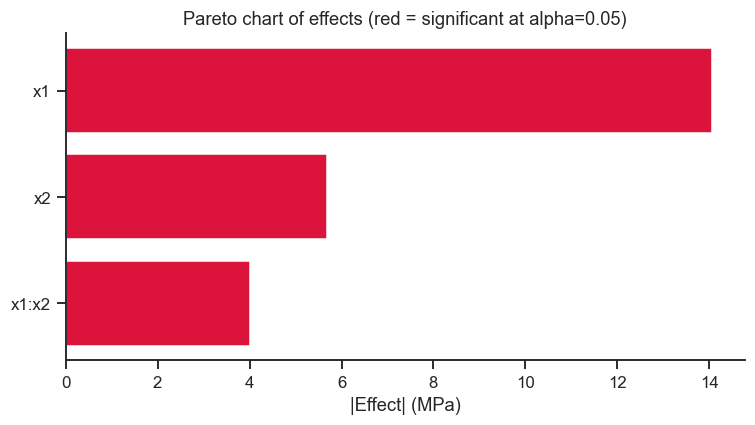

In [7]:
effects = 2 * model_full.params.drop('Intercept')
effects_abs = effects.abs().sort_values(ascending=True)

# A t-based significance threshold: an effect is 'significant' if its
# regression coefficient's p-value < 0.05 -- read directly off the model
sig = model_full.pvalues.drop('Intercept') < 0.05

fig, ax = plt.subplots(figsize=(7, 4))
colors_bar = ['crimson' if sig[t] else 'steelblue' for t in effects_abs.index]
ax.barh(effects_abs.index, effects_abs.values, color=colors_bar)
ax.set_xlabel('|Effect| (MPa)')
ax.set_title('Pareto chart of effects (red = significant at alpha=0.05)')
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

:::{admonition} Take-home message
:class: tip

All three bars are red — `x1` (14.06 MPa), `x2` (5.68 MPa), and `x1:x2`
(4.02 MPa) all clear the significance line, and all three land close to
their true built-in effects (12, 6, and 4 respectively, i.e. 2× the true
coefficients 6, 3, 2). Every bar being significant here, including the
smallest one, is itself informative: with only two factors and a
replicated design, there's little competition for the residual degrees
of freedom, so even a modest true effect (`x1:x2`) has a fair chance of
being detected — a very different situation from designs that spread the
same run budget across many more candidate terms.
:::

**Checkpoint / Exercise**: Which effects are significant? Do they match
the terms actually used to simulate `true_ILSS` in Section 22.1 (main
effects of 6 and 3, interaction of 2)? A design this small has few
degrees of freedom left for error — check whether that changes how
confidently you can call the smaller effect significant.

## 22.4 Centre Points: Testing for Curvature

Centre points earn their place in the design by doing something corner
points cannot: because $(0,0)$ is not part of the linear+interaction
model's fitted corners, comparing the **average response at the centre**
to the model's **predicted response at the centre** tests whether a
purely linear (planar) model is missing real curvature — the same
question RSM (Notebook 19) exists to answer with a full quadratic model,
asked here as a cheap yes/no check *before* committing to a much larger
RSM experiment.

In [8]:
center_runs = design_full[(design_full[['x1','x2']] == 0).all(axis=1)]
corner_runs_all = design_full[(design_full[['x1','x2']] != 0).all(axis=1)]

y_center_mean = center_runs['ILSS_MPa'].mean()
y_corner_mean = corner_runs_all['ILSS_MPa'].mean()   # ~= model's predicted value at (0,0)
predicted_at_center = model_full.params['Intercept']   # the model's own intercept IS its (0,0) prediction

print(f'Observed mean at centre points:      {y_center_mean:.2f} MPa  (n={len(center_runs)})')
print(f"Model's predicted value at (0,0):    {predicted_at_center:.2f} MPa  (= fitted intercept)")
print(f'Difference (possible curvature):     {y_center_mean - predicted_at_center:+.2f} MPa')

# Formal F-test for curvature: compare that difference to the pure-error
# variance estimated from the *replicated* centre points themselves
ss_curvature = (len(corner_runs_all) * len(center_runs) / (len(corner_runs_all) + len(center_runs))) * \
               (y_corner_mean - y_center_mean) ** 2
ss_pure_error = ((center_runs['ILSS_MPa'] - y_center_mean) ** 2).sum()
df_pure_error = len(center_runs) - 1
f_curvature = ss_curvature / (ss_pure_error / df_pure_error)
p_curvature = 1 - stats.f.cdf(f_curvature, 1, df_pure_error)
print(f'\nCurvature F-test: F={f_curvature:.2f}, p={p_curvature:.3f}')
print(f'{"Significant curvature detected -- a linear model is NOT adequate, consider RSM." if p_curvature < 0.05 else "No significant curvature -- the linear + interaction model is adequate."}')

Observed mean at centre points:      45.21 MPa  (n=3)
Model's predicted value at (0,0):    45.20 MPa  (= fitted intercept)
Difference (possible curvature):     +0.01 MPa

Curvature F-test: F=0.00, p=0.988
No significant curvature -- the linear + interaction model is adequate.


:::{admonition} Take-home message
:class: tip

The observed centre-point mean (45.21 MPa) and the model's predicted
value at (0,0) (45.20 MPa) differ by only +0.01 MPa — essentially nothing
against the noise level, giving F=0.00 and p=0.988. That's exactly what
should happen here: `true_ILSS` was built as a pure linear-plus-interaction
model with no quadratic term, so the linear model correctly finds no
curvature to detect. This is the check that would have caught a missing
quadratic term before committing to a full RSM study (Notebook 19) — see
Exercise 2 for what happens when curvature actually is present.
:::

## 22.5 Confirmation Run at the Predicted Optimum

A design is not finished when the ANOVA table is printed — the whole
point was to find better process settings, and you should never trust a
predicted optimum until you have actually run it. Using the significant
effects from Section 22.3's composite panel study, find the coded
settings that maximise predicted ILSS, then simulate a confirmation run
there and check it against the model's prediction interval.

In [9]:
# Grid-search the coded square [-1,1]^2 for the setting that maximises predicted ILSS
grid = np.array(list(product(np.linspace(-1, 1, 41), repeat=2)))
grid_df = pd.DataFrame(grid, columns=['x1', 'x2'])
grid_df['pred'] = model_full.predict(grid_df)
best = grid_df.loc[grid_df['pred'].idxmax()]
print(f"Predicted optimum (coded): x1={best.x1:.2f}, x2={best.x2:.2f}")
print(f'Predicted ILSS at optimum: {best.pred:.2f} MPa')

# Decode to real units
T_opt = 140 + best.x1 * 20     # coded -1/+1 <-> 120/160 C
t_opt = 4 + best.x2 * 2        # coded -1/+1 <-> 2/6 h
print(f'Decoded: T={T_opt:.0f} C, time={t_opt:.1f} h')

# Confirmation run: 3 fresh replicates at the predicted optimum
true_ILSS_at_optimum = 45 + 6*best.x1 + 3*best.x2 + 2*best.x1*best.x2
confirmation = true_ILSS_at_optimum + rng.normal(0, 1.2, 3)
print(f'\nConfirmation runs (n=3): {confirmation.round(2)}')

pred_summary = model_full.get_prediction(pd.DataFrame([best[['x1','x2']]])).summary_frame(alpha=0.05)
print(f"95% prediction interval: [{pred_summary['obs_ci_lower'].iloc[0]:.2f}, {pred_summary['obs_ci_upper'].iloc[0]:.2f}] MPa")
print(f"Confirmation mean {confirmation.mean():.2f} MPa -- "
      f"{'inside' if pred_summary['obs_ci_lower'].iloc[0] <= confirmation.mean() <= pred_summary['obs_ci_upper'].iloc[0] else 'OUTSIDE'} the prediction interval.")

Predicted optimum (coded): x1=1.00, x2=1.00
Predicted ILSS at optimum: 57.08 MPa
Decoded: T=160 C, time=6.0 h

Confirmation runs (n=3): [57.16 54.02 55.6 ]
95% prediction interval: [54.09, 60.07] MPa
Confirmation mean 55.59 MPa -- inside the prediction interval.


:::{admonition} Take-home message
:class: tip

The predicted optimum lands at x1=x2=1.00 — both factors simultaneously
at their *highest* tested level (160°C, 6 h). That is worth flagging
explicitly: it means ILSS was still increasing with both factors
everywhere this design looked, so a follow-up study extending the ranges
further (hotter, longer) could plausibly do even better — this design has
not bracketed a true interior optimum. The confirmation run (mean
55.59 MPa) landing inside the 95% prediction interval [54.09, 60.07] is
the whole point of Section 22.5: the model's prediction wasn't just
trusted on paper, it was checked against a fresh, independent measurement
before treating it as a real process recommendation.
:::

---
## Exercises

**Core practice**

1. **Extend to a third factor**: Add fibre volume fraction (40%/60%) as a
   third factor to the composite-panel study, simulate a replicated $2^3$
   with centre points, and redo Sections 22.2–22.4 for it. Does the new
   factor's main effect turn out significant? (Notebook 24, Live Tutorial 3
   picks up exactly this thread — many-factor screening designs — where
   this notebook leaves off.)

2. **Curvature, deliberately added**: Add a true quadratic term to
   `true_ILSS` in Section 22.1 (e.g. `- 3 * x1**2`) and rerun Section
   22.4's curvature F-test. Confirm it now correctly flags significant
   curvature, and explain in one sentence what an engineer should do next
   given that result.

3. **Confirmation run outside the interval**: Deliberately shift the
   confirmation-run simulation in Section 22.5 by adding a constant offset
   (e.g. `+ 4` MPa, representing an unmodelled process drift between the
   original experiment and the confirmation run) and rerun the check.
   What would *you* conclude, as the engineer, if your real confirmation
   run fell outside the predicted interval like this?

**Deeper practice**

4. **Design your own 2² study**: Pick a process from earlier in the course
   (ZnO synthesis, NMC cathode sintering, TiO₂ thin films) and design a
   fresh $2^2$-with-centre-points study on it, following Sections
   22.1–22.5 end to end: build the design, simulate a response with a
   genuine interaction and no curvature, run the full analysis, and
   produce your own Pareto chart and confirmation run.